**Goal:** build your first regression model -- predict a *quantity* instead of a label
-- and learn to judge it against the laziest possible competitor. Pairs with the
concept note [The Supervised Learning Problem and Linear
Regression](l03_concept_linear_regression.qmd).

> **Previously:** L02 -- The ML Toolkit and Your First Model  |  **Next:** L04 -- Logistic Regression

> This page is the read-only view. To run the lab, open the notebook
> (`l03_lab_linear_regression.ipynb`) -- in Colab via the badge on the concept page, or locally.

## Scenario

A coffee cooperative in Puerto Rico's central mountains manages 120 small plots. Every
January the co-op must commit to buyers before the harvest exists, so it wants to
predict each plot's annual yield (kg of coffee cherry) from what is measurable now:
the plot's area (in cuerdas, the PR land unit), the average age of its trees, and how
much shade cover it sits under.

The data below is **synthetic** (generated with a fixed seed, so everyone gets
identical numbers) with *fictionalized but plausible* values -- the framing is real,
the kilograms are not field measurements.

## Setup

The setup is **two cells** (this is the pattern every lab in the course uses). Run them top
to bottom. The first only installs; the second imports, seeds the random number generator,
and builds the data -- so when you re-run imports while experimenting, you do not re-install.

In [1]:
# Setup, cell 1 of 2 -- INSTALL (run once; Colab wipes installs when it resets on open)
# Colab already ships scikit-learn, numpy, pandas and matplotlib, so this is effectively a
# no-op there; it models the install step. Locally the uv equivalent is the comment below.
%pip install -q scikit-learn
# local, in a terminal (not in the notebook):  uv add scikit-learn numpy pandas matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Setup, cell 2 of 2 -- IMPORTS, SEED, DATA (safe to re-run without re-installing)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)          # fixed seed: identical data for everyone
n = 120                                  # plots managed by the co-op

plots = pd.DataFrame({
    "area_cuerdas": rng.uniform(1.0, 3.0, n).round(2),
    "tree_age_yr":  rng.uniform(3, 25, n).round(1),
    "shade_pct":    rng.uniform(20, 80, n).round(0),
})
plots["yield_kg"] = (100 + 200*plots["area_cuerdas"] + 18*plots["tree_age_yr"]
                     - 4*plots["shade_pct"] + rng.normal(0, 70, n)).round(1)
print(plots.shape)
plots.head(3)

(120, 4)


,area_cuerdas,tree_age_yr,shade_pct,yield_kg
0,2.55,15.9,70.0,574.8
1,1.88,17.3,68.0,556.8
2,2.72,4.9,34.0,485.5


~~~text
(120, 4)
   area_cuerdas  tree_age_yr  shade_pct  yield_kg
0          2.55         15.9       70.0     574.8
1          1.88         17.3       68.0     556.8
2          2.72          4.9       34.0     485.5
~~~

Split first -- the honesty habit from L02. We hold out a test set *before* looking at
any model, and every model in this lab will be graded on those same 30 unseen plots:

In [3]:
from sklearn.model_selection import train_test_split

features = ["area_cuerdas", "tree_age_yr", "shade_pct"]
X_train, X_test, y_train, y_test = train_test_split(
    plots[features], plots["yield_kg"], test_size=0.25, random_state=42)
print(len(X_train), "training plots /", len(X_test), "test plots")

90 training plots / 30 test plots


~~~text
90 training plots / 30 test plots
~~~

## Step 1: Beat the Laziest Model

Always plot first. Yield against area looks like the obvious place to start:

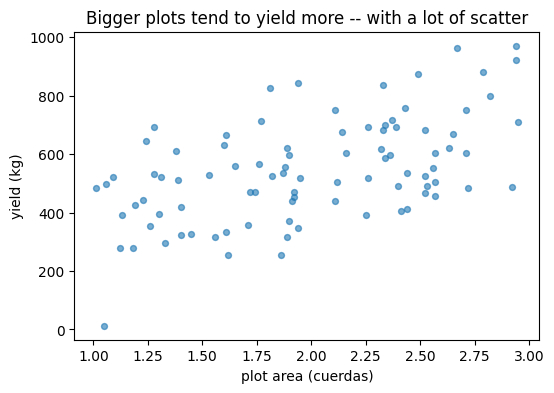

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(X_train["area_cuerdas"], y_train, alpha=0.6, s=18)
ax.set_xlabel("plot area (cuerdas)")
ax.set_ylabel("yield (kg)")
ax.set_title("Bigger plots tend to yield more -- with a lot of scatter")
plt.show()

There is an upward trend, but it is noisy: plots of the same size differ by hundreds
of kilograms. Some of that spread must come from the features we have not used yet.

### Naive approach: predict the average for everyone

Before any model earns our respect, it has to beat the laziest possible predictor:
ignore the features and predict the training-set mean yield for every plot.

In [5]:
from sklearn.metrics import mean_squared_error, r2_score

mean_yield = y_train.mean()
baseline_pred = np.full(len(y_test), mean_yield)
print(f"mean yield (train): {mean_yield:.1f}")
print(f"baseline MSE: {mean_squared_error(y_test, baseline_pred):.0f}  R2: {r2_score(y_test, baseline_pred):.3f}")

mean yield (train): 546.1
baseline MSE: 31053  R2: -0.000


~~~text
mean yield (train): 546.1
baseline MSE: 31053  R2: -0.000
~~~

By construction, R^2 measures "how much better than this baseline" -- so the baseline
itself scores essentially zero. (It reads -0.000 rather than exactly zero because the
test plots' own mean differs slightly from the *training* mean we predicted; on its
own training data the baseline would score exactly 0.) The MSE of 31053 kg^2 is the
error bar to beat.

### Better approach: learn a line from the data

In [6]:
from sklearn.linear_model import LinearRegression

simple = LinearRegression().fit(X_train[["area_cuerdas"]], y_train)
simple_pred = simple.predict(X_test[["area_cuerdas"]])
print(f"slope: {simple.coef_[0]:.1f}  intercept: {simple.intercept_:.1f}")
print(f"simple MSE: {mean_squared_error(y_test, simple_pred):.0f}  R2: {r2_score(y_test, simple_pred):.3f}")

slope: 174.5  intercept: 199.0
simple MSE: 21207  R2: 0.317


~~~text
slope: 174.5  intercept: 199.0
simple MSE: 21207  R2: 0.317
~~~

Read the slope the way the concept note taught: **each extra cuerda predicts about 175
more kilograms of cherry**. The line explains about 32% of the yield variance on
unseen plots -- a real improvement over the baseline, and clearly not the whole story.

Draw the fitted line over the data, then look at what it leaves behind:

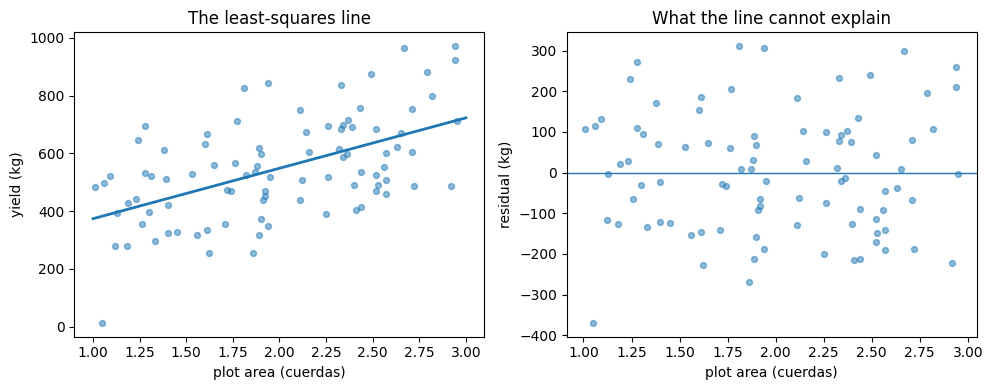

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

xs = np.linspace(1.0, 3.0, 50).reshape(-1, 1)
axes[0].scatter(X_train["area_cuerdas"], y_train, alpha=0.5, s=18)
axes[0].plot(xs, simple.predict(pd.DataFrame(xs, columns=["area_cuerdas"])), linewidth=2)
axes[0].set_xlabel("plot area (cuerdas)")
axes[0].set_ylabel("yield (kg)")
axes[0].set_title("The least-squares line")

residuals = y_train - simple.predict(X_train[["area_cuerdas"]])
axes[1].scatter(X_train["area_cuerdas"], residuals, alpha=0.5, s=18)
axes[1].axhline(0, linewidth=1)
axes[1].set_xlabel("plot area (cuerdas)")
axes[1].set_ylabel("residual (kg)")
axes[1].set_title("What the line cannot explain")
plt.tight_layout()
plt.show()

The right panel shows the **residuals**: actual minus predicted, one point per
training plot. They are centered on zero (the line is not biased up or down) but they
spread roughly 150 kg either way -- and that spread is information sitting in
`tree_age_yr` and `shade_pct`, which this model never saw.

## Step 2: Use All the Features -- completion problem

Multiple linear regression is the same recipe with a wider table: one coefficient per
feature. Complete the marked lines:

In [8]:
# Uncomment and complete the marked lines:
# multi = LinearRegression().fit(____, ____)        # fit on ALL THREE training features
# multi_pred = multi.predict(____)                  # predict the TEST plots
# print("coefficients:", dict(zip(features, multi.coef_.round(1))))
# print(f"intercept: {multi.intercept_:.1f}")
# print(f"multi MSE: {mean_squared_error(y_test, multi_pred):.0f}  R2: {r2_score(y_test, multi_pred):.3f}")
#
# new_plot = pd.DataFrame({"area_cuerdas": [2.0], "tree_age_yr": [12.0], "shade_pct": [40.0]})
# print(f"predicted yield for the new plot: {multi.predict(new_plot)[0]:.0f} kg")

<details><summary>Expected Output</summary>

~~~text
coefficients: {'area_cuerdas': 189.8, 'tree_age_yr': 17.1, 'shade_pct': -4.2}
intercept: 145.1
multi MSE: 5762  R2: 0.814
predicted yield for the new plot: 561 kg
~~~

From 32% to 81% of the variance explained, on the same held-out plots, just by letting
the model see all three features. Read the coefficients: each cuerda is worth about
190 kg, each year of tree age about 17 kg, and each percentage point of shade *costs*
about 4 kg -- a **negative** coefficient. Shade-grown plots yield less volume (the
co-op accepts that trade for quality). Note the units differ per feature, so the raw
sizes of coefficients are not comparable with each other.
</details>

## Your Turn

### Exercise 1 -- The best single feature

We started with area because it made the prettiest scatter plot. Was that actually the
strongest single predictor? Fit one single-feature model per column and compare.

**Hint:** loop over `features`, fit `LinearRegression` on `X_train[[f]]`, and print each test R^2.

In [9]:
# TODO: your code here

<details><summary>Expected Output</summary>

~~~text
area_cuerdas: test R2 = 0.317
tree_age_yr: test R2 = 0.523
shade_pct: test R2 = 0.159
~~~

Surprise: **tree age** beats area. The feature that looked most obvious on a plot was
not the most informative one -- which is why we measure instead of eyeballing. Note
that 0.317 + 0.523 + 0.159 does not add up to the 0.814 of Step 2: features share
information, and the combined model sorts out their joint contribution.
</details>

### Exercise 2 -- A useless feature

Suppose the co-op also recorded `rooster_count`, the number of roosters living near
each plot -- pure noise, no causal link to yield. Add it, refit the multiple
regression, and check: does the model get fooled?

**Hint:** add the column with `rng2 = np.random.default_rng(0)` and `rng2.integers(0, 10, n)`,
rebuild the split with the four features (same `test_size` and `random_state`), and refit.

In [10]:
# TODO: your code here

<details><summary>Expected Output</summary>

~~~text
coefficients: {'area_cuerdas': 188.3, 'tree_age_yr': 17.3, 'shade_pct': -4.2, 'rooster_count': -2.2}
test R2 = 0.810
~~~

The model assigns the roosters a tiny coefficient (about -2 kg per rooster, against
yields in the hundreds) and the test R^2 actually slipped a little (0.810 vs 0.814).
Junk features do not help, and they can quietly hurt -- with many of them, the damage
stops being quiet. Unit III gives this problem its real name and its remedies.
</details>

## Summary

- A regression model must **beat the predict-the-mean baseline** on held-out data, or
  it has learned nothing; R^2 is exactly that comparison.
- Coefficients are read in target-units per feature-unit: about 190 kg per cuerda,
  about -4 kg per percent of shade. Sign and size are the model's story.
- More features helped here (0.317 to 0.814) because each carried real signal; the
  rooster column shows that irrelevant features add nothing and can subtract.
- Next (L04): the same linear machinery aimed at **labels instead of quantities** --
  classification with logistic regression.